In [ ]:
# import require python package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load data set and check the shape
df_auto = pd.read_csv('/content/Auto.csv')
df_auto = df_auto[~(df_auto['horsepower'] == '?')]
print('Dataset Shape:',df_auto.shape)

Dataset Shape: (392, 9)


In [ ]:
# check datatypes and null
df_auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    object 
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 30.6+ KB


In [ ]:
# Get Predictor, response and fit model
X = pd.DataFrame({
    'intercept': np.ones(df_auto.shape[0]),
    'horsepower': pd.to_numeric(df_auto['horsepower'])
})

y = df_auto['mpg']

# fit the model
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sun, 17 Aug 2025   Prob (F-statistic):           7.03e-81
Time:                        15:03:49   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     39.9359      0.717     55.660      0.0

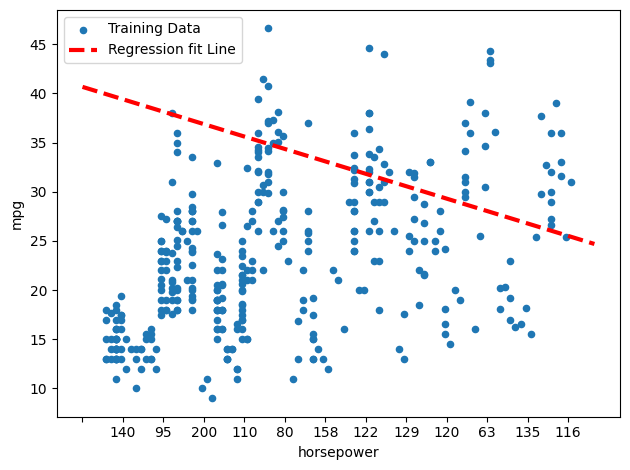

In [ ]:
# define utility function to draw regression fit line
def abline(ax, b, m, *args, **kwargs):
  "Add a line with slope m and intercept b to ax"
  xlim = ax.get_xlim()
  ylim = [m * xlim[0] + b, m * xlim[1] + b]
  ax.set_xticks(np.arange(xlim[0], xlim[1], 8))
  ax.plot(xlim, ylim, *args, **kwargs)

# plot the data and draw regression fit line
ax = df_auto.plot.scatter('horsepower','mpg', label='Training Data')
abline(
   ax,
   results.params[0],
   results.params[1],
   'r--',
   linewidth=3,
   label = 'Regression fit Line'
)

plt.legend()
plt.tight_layout()
#plt.title('mpg Vs horsepower')
plt.show()


In [ ]:
# Do prediction and get confidence / Prediction interval
new_df = pd.DataFrame({'intercept': 1, 'horsepower': [98]})
new_predictions = results.get_prediction(new_df)
print('Prediction:', new_predictions.predicted_mean[0])
print('Confidence interval:',new_predictions.conf_int(alpha = 0.05))
print('Prediction interval:', new_predictions.conf_int(obs=True, alpha=0.05))

Prediction: 24.46707715251243
Confidence interval: [[23.97307896 24.96107534]]
Prediction interval: [[14.80939607 34.12475823]]


# Summary
1.   Is there a relationship between the predictor and the response?

  *   Yes , p value is far below from statistical signification (0.05) hence there is a strong relationship

2.   How strong is the relationship between the predictor and
the response?

  *   Coefficient of horsepower is negative (-0.1578) means mpg is decreasing by .1578 for every hoursepower
3.  Is the relationship between the predictor and the response
positive or negative?
  *     Negative
4.  What is the predicted mpg associated with a horsepower of
98? What are the associated 95 % confidence and prediction
intervals?
  * Prediction: 24.46707715251243
  * Confidence interval: [[23.97307896 24.96107534]]
  * Prediction interval: [[14.80939607 34.12475823]]

